In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/content/spam (1).csv', encoding='latin1')

In [ ]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3533,ham,Good evening! How are you?,NaN,NaN,NaN
1823,ham,Same as u... Dun wan... Y u dun like me alread...,NaN,NaN,NaN
5097,ham,Sorry about that this is my mates phone and i ...,NaN,NaN,NaN
3799,spam,We tried to contact you re your reply to our o...,NaN,NaN,NaN
2881,ham,Hi Harish's rent has been transfred to ur Acnt.,NaN,NaN,NaN


In [ ]:
df.shape

(5572, 5)

In [ ]:
# 1)Data cleaning
# 2)EDA
# 3)Text preprocessing
# 4)model building
# 5)Evaluation
# 6)Improvement
# 7)Website
# 8)Deploy

#1.Data Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
# drop last 3 cols
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [ ]:
df.sample(5)

,v1,v2
3347,ham,"Sorry, I'll call later"
1521,ham,Are you angry with me. What happen dear
750,spam,"Do you realize that in about 40 years, we'll h..."
5186,ham,I uploaded mine to Facebook
3081,ham,"And very importantly, all we discuss is betwee..."


In [ ]:
# renaming the columns
df.rename(columns={'v1': 'target','v2': 'text'})

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [ ]:
df = df[['v1', 'v2']]
df.columns = ['target', 'text']

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [ ]:
# missing values
df.isnull().sum()

,0
target,0
text,0


In [ ]:
df.duplicated().sum()

np.int64(403)

In [ ]:
df.drop_duplicates(keep='first')

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [ ]:
df.shape

(5572, 2)

#2.EDA

In [ ]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df['target'].value_counts()

,count
target,
0,4825
1,747


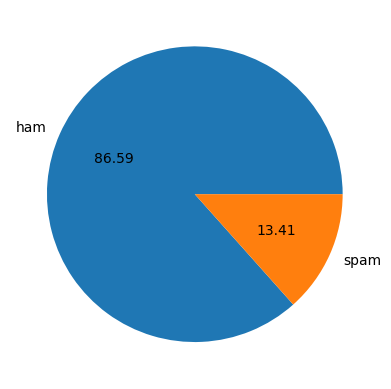

In [ ]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%0.2f')
plt.show()

In [ ]:
# data is imbalance

In [ ]:
pip install nltk

In [ ]:
import nltk

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
df['num_char'] = df['text'].apply(len)

In [ ]:
# num of words
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [ ]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [ ]:
df.head()

,target,text,num_char,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [ ]:
df[['num_char','num_words','num_sentences']].describe()

,num_char,num_words,num_sentences
count,5572.000000,5572.000000,5572.000000
mean,80.118808,18.699390,1.996411
std,59.690841,13.741932,1.520159
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.500000
75%,121.000000,27.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
df[df['target'] == 0][['num_char','num_words','num_sentences']].describe()

,num_char,num_words,num_sentences
count,4825.000000,4825.000000,4825.000000
mean,71.023627,17.276269,1.837720
std,58.016023,13.988585,1.454388
min,2.000000,1.000000,1.000000
25%,33.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,92.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
df[df['target'] == 1][['num_char','num_words','num_sentences']].describe()

,num_char,num_words,num_sentences
count,747.000000,747.000000,747.000000
mean,138.866131,27.891566,3.021419
std,29.183082,6.867007,1.537580
min,13.000000,2.000000,1.000000
25%,132.500000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [ ]:
import seaborn as sns

<Axes: xlabel='num_char', ylabel='Count'>

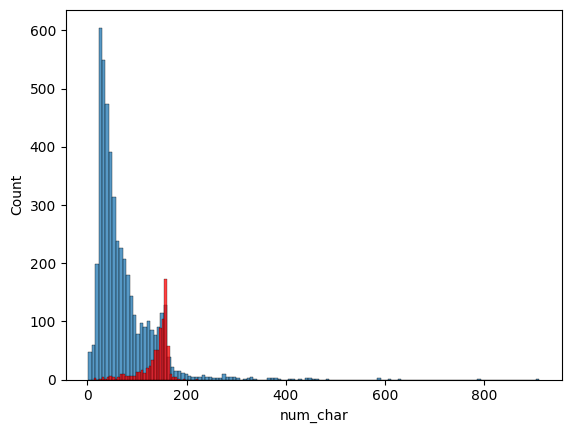

In [ ]:
sns.histplot(df[df['target'] == 0]['num_char'])
sns.histplot(df[df['target'] == 1]['num_char'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

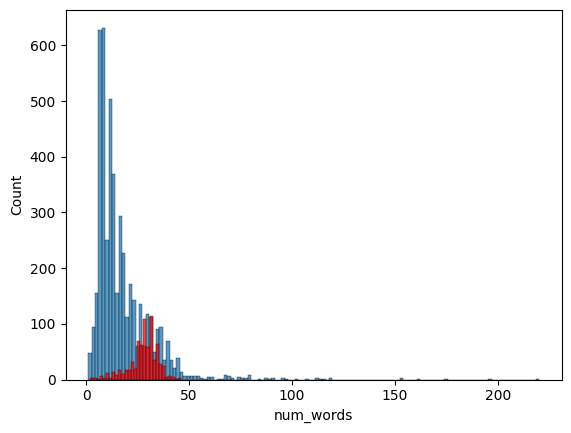

In [ ]:
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

<Axes: xlabel='num_sentences', ylabel='Count'>

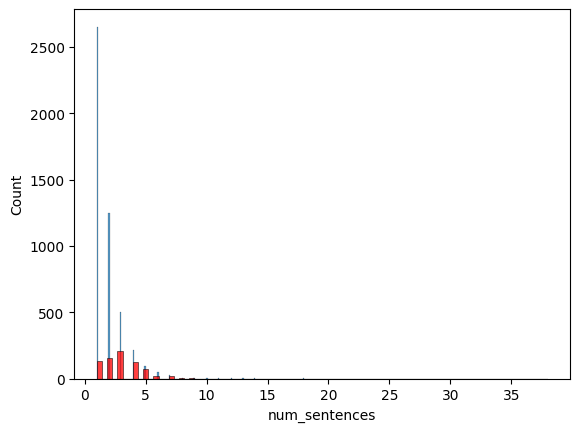

In [ ]:
sns.histplot(df[df['target'] == 0]['num_sentences'])
sns.histplot(df[df['target'] == 1]['num_sentences'],color='red')

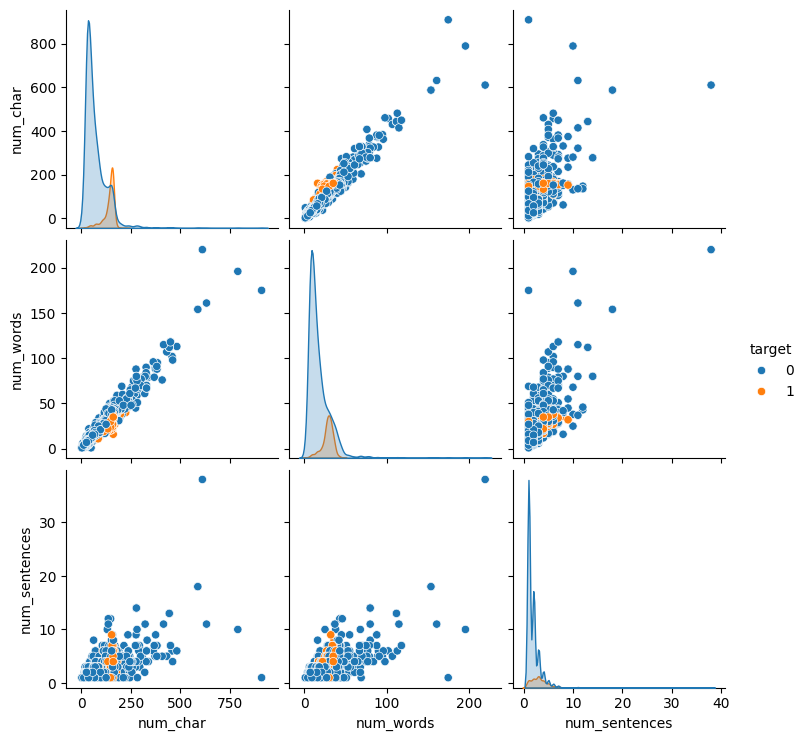

In [ ]:
sns.pairplot(df,hue='target')

<Axes: >

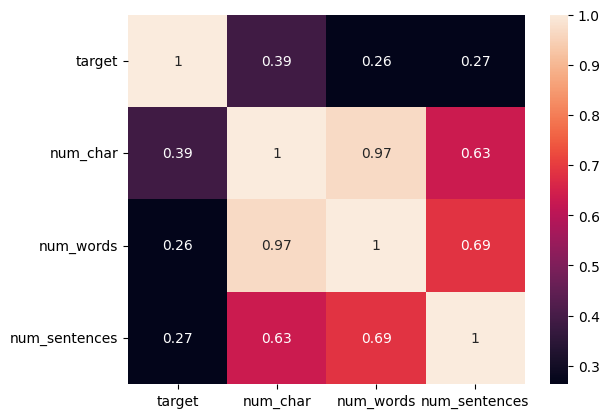

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

#3.Data Preprocessing


In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
import string
import nltk
from nltk.corpus import stopwords

def transform_text(text):
  # lower case
  text = text.lower()
  # tokenize
  text = nltk.word_tokenize(text)

  # Removing special characters
  y = []
  for i in text:
    if i.isalnum():
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
     if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  # Stemming
  text = y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))


  return ' '.join(y)

In [ ]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [ ]:
df['transformed_text'] = df['text'].apply(transform_text)

In [ ]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, background_color='white')

In [ ]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

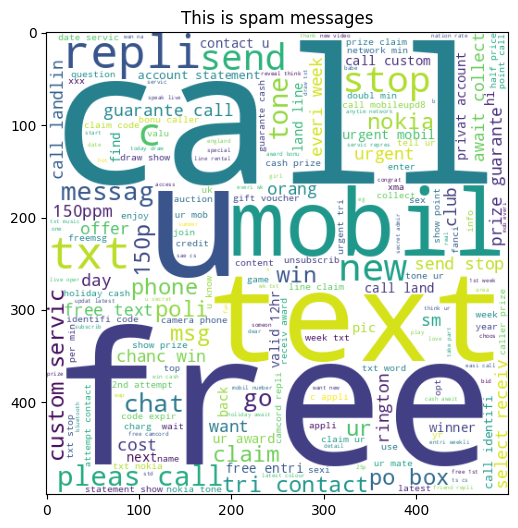

In [ ]:
plt.figure(figsize=(12,6))
plt.title('This is spam messages')
plt.imshow(spam_wc)

In [ ]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

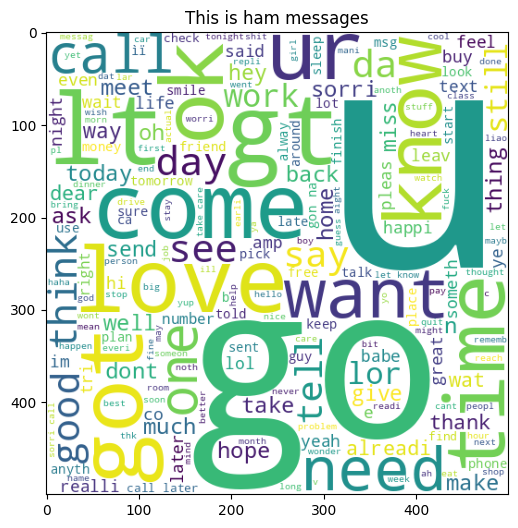

In [ ]:
plt.figure(figsize=(12,6))
plt.title('This is ham messages')
plt.imshow(ham_wc)

In [ ]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)

In [ ]:
len(spam_corpus)

11490

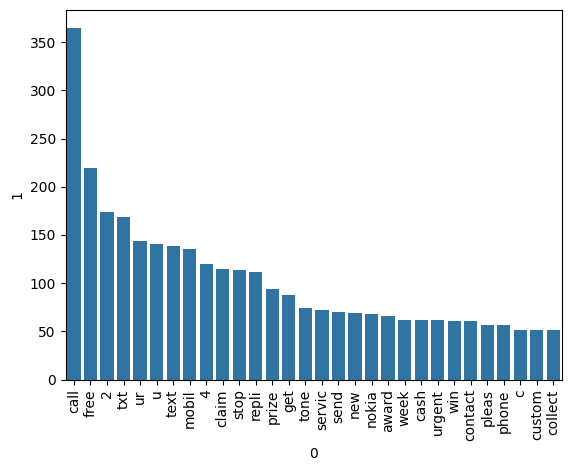

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
sns.barplot(
    x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],
    y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1]
)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
  for word in msg.split():
    ham_corpus.append(word)

In [ ]:
len(ham_corpus)

38221

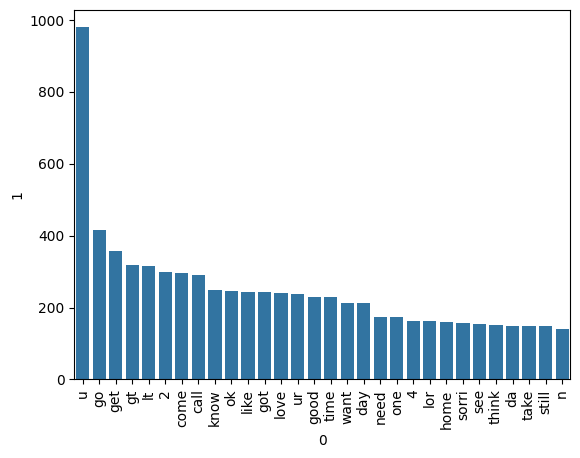

In [ ]:
from collections import Counter
sns.barplot(
    x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0],
    y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1]
)
plt.xticks(rotation='vertical')
plt.show()

#4.Model Building

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [ ]:
x = tfidf.fit_transform(df['transformed_text']).toarray()

In [ ]:
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()
# x = scaler.fit_transform(x)

In [ ]:

# x = np.hstack((x, df['num_char'].to_numpy().reshape(-1, 1)))

In [ ]:
x.shape

(5572, 3000)

In [ ]:
y = df['target'].values

In [ ]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=2)

In [ ]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [ ]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [ ]:
gnb.fit(x_train, y_train)
y_pred1 = gnb.predict(x_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.884304932735426
[[858  99]
 [ 30 128]]
0.5638766519823789


In [ ]:
mnb.fit(x_train, y_train)
y_pred2 = mnb.predict(x_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.9650224215246637
[[956   1]
 [ 38 120]]
0.9917355371900827


In [ ]:
bnb.fit(x_train, y_train)
y_pred3 = bnb.predict(x_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.9757847533632287
[[956   1]
 [ 26 132]]
0.9924812030075187


In [ ]:
# tfidf ---> MNB

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [ ]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(penalty='l1', solver='liblinear')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)

In [ ]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC' : bc,
    'ETC': etc,
    'GBDT': gbdt,
    'xgb' : xgb
}

In [ ]:
from sklearn.metrics import accuracy_score, precision_score

# def train_classfrom sklearn.metrics import accuracy_score, precision_score

def train_classifier(clf, x_train, y_train, x_test, y_test):
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    return accuracy, precision

In [ ]:
train_classifier(svc, x_train, y_train, x_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(0.8582959641255605, 0.0)

In [ ]:
accuracies = []
precisions = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(
        clf, x_train, y_train, x_test, y_test
    )

    print("For", name)
    print("Accuracy:", current_accuracy)
    print("Precision:", current_precision)

    accuracies.append(current_accuracy)
    precisions.append(current_precision)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


For SVC
Accuracy: 0.8582959641255605
Precision: 0.0
For KN
Accuracy: 0.9192825112107623
Precision: 0.7741935483870968
For NB
Accuracy: 0.9390134529147982
Precision: 0.9891304347826086
For DT
Accuracy: 0.9434977578475336
Precision: 0.9279279279279279
For LR
Accuracy: 0.9551569506726457
Precision: 0.9576271186440678
For RF
Accuracy: 0.9713004484304932
Precision: 1.0
For AdaBoost
Accuracy: 0.9363228699551569
Precision: 0.9223300970873787
For BgC
Accuracy: 0.9596412556053812
Precision: 0.9064748201438849
For ETC
Accuracy: 0.9739910313901345
Precision: 0.9923664122137404
For GBDT
Accuracy: 0.9488789237668162
Precision: 0.9469026548672567
For xgb
Accuracy: 0.967713004484305
Precision: 0.9841269841269841


In [ ]:
performance_df = pd.DataFrame({
    'Algorithms': list(clfs.keys()),
    'Accuracy': accuracies,
    'Precision': precisions
}).sort_values('Precision', ascending=False)


In [ ]:
performance_df

,Algorithms,Accuracy,Precision
5,RF,0.971300,1.000000
8,ETC,0.973991,0.992366
2,NB,0.939013,0.989130
10,xgb,0.967713,0.984127
4,LR,0.955157,0.957627
9,GBDT,0.948879,0.946903
3,DT,0.943498,0.927928
6,AdaBoost,0.936323,0.922330
7,BgC,0.959641,0.906475
1,KN,0.919283,0.774194


In [ ]:
performance_df1 = pd.melt(performance_df, id_vars = 'Algorithms')

In [ ]:
performance_df1

,Algorithms,variable,value
0,RF,Accuracy,0.971300
1,ETC,Accuracy,0.973991
2,NB,Accuracy,0.939013
3,xgb,Accuracy,0.967713
4,LR,Accuracy,0.955157
5,GBDT,Accuracy,0.948879
6,DT,Accuracy,0.943498
7,AdaBoost,Accuracy,0.936323
8,BgC,Accuracy,0.959641
9,KN,Accuracy,0.919283


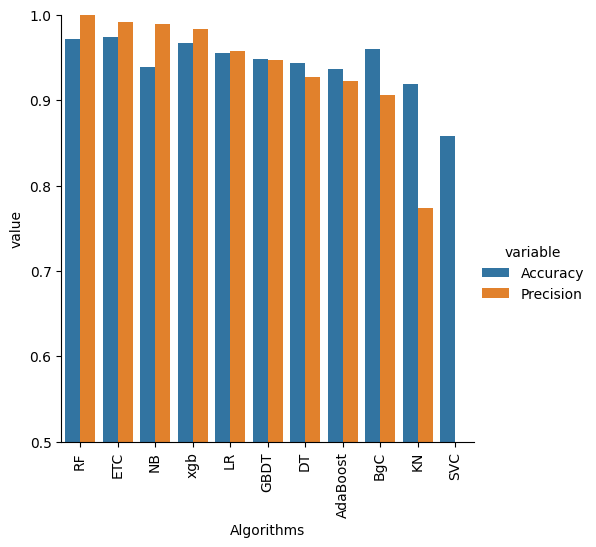

In [ ]:
sns.catplot(x = 'Algorithms', y= 'value',
            hue='variable', data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
# model improve
# 1. Change the max_feature parameter of TfIdf

In [ ]:
temp_df = pd.DataFrame({
    'Algorithms': list(clfs.keys()),
    'Accuracy_max_ft_3000':accuracies,
    'Precision_max_ft_3000':precisions})

In [ ]:
performance_df.merge(temp_df, on='Algorithms')

,Algorithms,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000
0,RF,0.971300,1.000000,0.971300,1.000000
1,ETC,0.973991,0.992366,0.973991,0.992366
2,NB,0.939013,0.989130,0.939013,0.989130
3,xgb,0.967713,0.984127,0.967713,0.984127
4,LR,0.955157,0.957627,0.955157,0.957627
5,GBDT,0.948879,0.946903,0.948879,0.946903
6,DT,0.943498,0.927928,0.943498,0.927928
7,AdaBoost,0.936323,0.922330,0.936323,0.922330
8,BgC,0.959641,0.906475,0.959641,0.906475
9,KN,0.919283,0.774194,0.919283,0.774194


In [ ]:
new_df = pd.DataFrame({
    'Algorithms': list(clfs.keys()),
    'Accuracy_scalling':accuracies,
    'Precision_scalling':precisions})

In [ ]:
new_df_scaled = new_df.merge(temp_df, on='Algorithms')

In [ ]:
new_df_scaled

,Algorithms,Accuracy_scalling,Precision_scalling,Accuracy_max_ft_3000,Precision_max_ft_3000
0,SVC,0.858296,0.000000,0.858296,0.000000
1,KN,0.919283,0.774194,0.919283,0.774194
2,NB,0.939013,0.989130,0.939013,0.989130
3,DT,0.943498,0.927928,0.943498,0.927928
4,LR,0.955157,0.957627,0.955157,0.957627
5,RF,0.971300,1.000000,0.971300,1.000000
6,AdaBoost,0.936323,0.922330,0.936323,0.922330
7,BgC,0.959641,0.906475,0.959641,0.906475
8,ETC,0.973991,0.992366,0.973991,0.992366
9,GBDT,0.948879,0.946903,0.948879,0.946903


In [ ]:
# vocting classifier
svc = SVC(kernel='sigmoid', gamma=1.0, probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=42)

from sklearn.ensemble import VotingClassifier

In [ ]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)], voting='soft')

In [ ]:
voting.fit(x_train, y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=42))],
                 voting='soft')

In [ ]:
VotingClassifier(estimators=[('svm',SVC(gamma=1.0, kernel='sigmoid',probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                                                   voting='soft')

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [ ]:
y_pred = voting.predict(x_test)
print('Accuracy', accuracy_score(y_test, y_pred))
print('Precision', precision_score(y_test, y_pred))


Accuracy 0.9408071748878923
Precision 1.0


In [ ]:
# applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimators=RandomForestClassifier()

In [ ]:
from sklearn.ensemble import StackingClassifier

In [ ]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimators)

In [ ]:
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
print('Accuracy', accuracy_score(y_test, y_pred))
print('Precision', precision_score(y_test, y_pred))

In [ ]:
import pickle
pickle.dump(tfidf, open('verctorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl','wb'))